# M3: Stock–Watson soft factor and short-window horse race

The short-window soft block has six variables (UMCSENT, EPU, NY Fed, Philly
Fed, Dallas Fed, SLOOS). Throwing all six into a VAR alongside the hard
block would be 13 variables on ~80 monthly observations — vastly
overparameterized. The Stock–Watson move is to extract a single principal
component from the standardized soft block and treat that factor as the
*one* soft summary. We drop SLOOS for the factor (it's quarterly and would
force complete-case rows to be sparse) and use the five monthly soft
indicators.

**What's in this notebook**

1. Factor diagnostics: how stable are loadings across recursive refits?
2. Factor history: what does the factor look like over time?
3. Short-window horse race: hard-only vs hard+UMCSENT vs hard+soft-factor.
4. Caveats and tee-up to STVAR.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from fredapi import Fred

from load_config import load_config
from evaluation.feature_frame import load_inputs, build_feature_frame
from models.soft_factor import SoftFactor

ROOT = Path.cwd().parent
cfg = load_config(str(ROOT / 'configs/us.yaml'), secrets_path=str(ROOT / 'config.yaml'))
fred = Fred(api_key=cfg['api_key'])
cubes, static = load_inputs(cfg, fred, cube_dir=str(ROOT / 'data/vintages/cubes'))

SOFT = ['consumer_sentiment', 'epu', 'empire_state_mfg', 'philly_fed_mfg', 'dallas_fed_mfg']

from evaluation.harness import monthly_origins
ORIGINS = monthly_origins('2018-01-01', '2024-12-01')

## 1. Loadings across recursive refits

If the factor is well-behaved, the loadings should be stable across origins
(adding one more month of data shouldn't completely rearrange the factor).

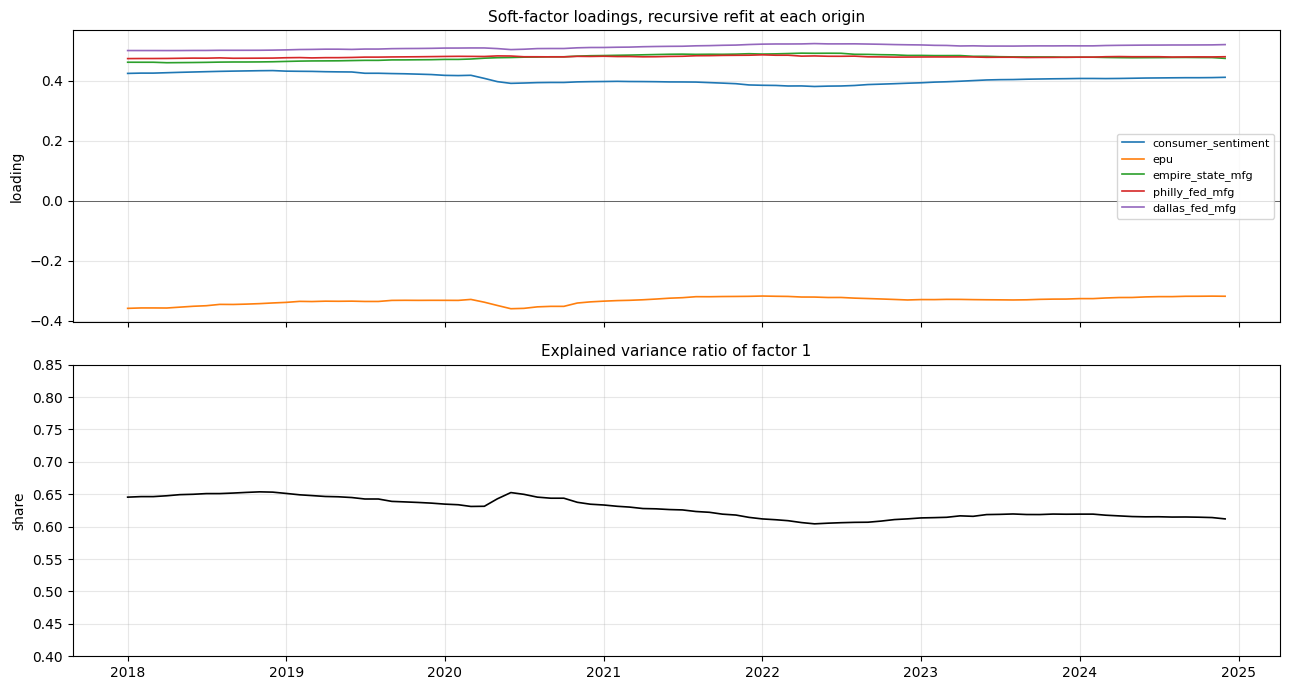

Loading stats across 84 refits:
      consumer_sentiment    epu  empire_state_mfg  philly_fed_mfg  dallas_fed_mfg
mean               0.407 -0.333             0.478           0.480           0.513
std                0.016  0.012             0.010           0.003           0.007
min                0.381 -0.360             0.461           0.474           0.501
max                0.434 -0.318             0.493           0.487           0.525

Explained variance ratio: mean 0.629, range [0.604, 0.654]


In [2]:
loadings_over_time = []
evr_over_time = []
for origin in ORIGINS:
    raw_ff = build_feature_frame(cfg, cubes, static, origin, variables=SOFT)
    try:
        sf = SoftFactor(SOFT, n_components=1, sign_reference='consumer_sentiment').fit(raw_ff)
        loadings_over_time.append(sf.loadings_['f1'].rename(origin))
        evr_over_time.append((origin, sf.explained_variance_ratio_[0]))
    except ValueError:
        continue
L = pd.DataFrame(loadings_over_time)
evr = pd.Series(dict(evr_over_time))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for col in L.columns:
    axes[0].plot(L.index, L[col], lw=1.2, label=col)
axes[0].set_title('Soft-factor loadings, recursive refit at each origin', fontsize=11)
axes[0].set_ylabel('loading'); axes[0].legend(fontsize=8, loc='best'); axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='black', lw=0.4)
axes[1].plot(evr.index, evr.values, color='black', lw=1.2)
axes[1].set_title('Explained variance ratio of factor 1', fontsize=11)
axes[1].set_ylabel('share'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.4, 0.85)
plt.tight_layout(); plt.show()

print(f'Loading stats across {len(L)} refits:')
print(L.agg(['mean','std','min','max']).round(3).to_string())
print(f'\nExplained variance ratio: mean {evr.mean():.3f}, range [{evr.min():.3f}, {evr.max():.3f}]')

## 2. Factor history at the latest refit

What the factor looks like as a time series, using loadings from the most
recent (full-sample) refit. The COVID shock and 2022 inflation episode
should be visible.

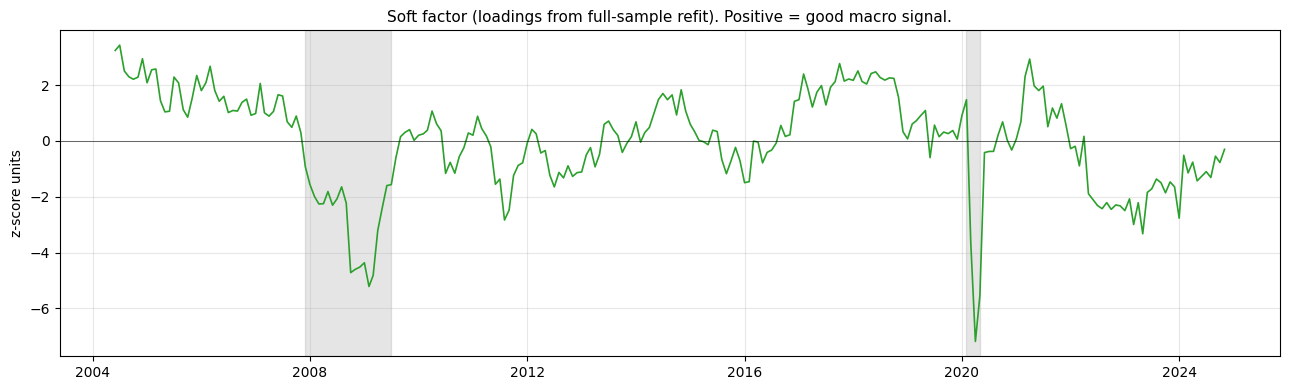

In [3]:
as_of = pd.Timestamp('2024-12-01')
ff = build_feature_frame(cfg, cubes, static, as_of, variables=SOFT)
sf = SoftFactor(SOFT, n_components=1, sign_reference='consumer_sentiment').fit(ff)
scores = sf.transform(ff).dropna()

nber = fred.get_series('USRECM').reindex(pd.date_range('2004-01-01','2024-12-01', freq='MS'))
def recession_bands(s):
    s = s.fillna(0).astype(int); out, in_rec, start = [], False, None
    for d, v in s.items():
        if v == 1 and not in_rec: start, in_rec = d, True
        elif v == 0 and in_rec:   out.append((start, d)); in_rec = False
    if in_rec: out.append((start, s.index[-1]))
    return out
BANDS = recession_bands(nber)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(scores.index, scores['soft_f1'], lw=1.2, color='#2ca02c')
for s_, e_ in BANDS:
    ax.axvspan(s_, e_, color='grey', alpha=0.2)
ax.axhline(0, color='black', lw=0.4)
ax.set_title('Soft factor (loadings from full-sample refit). Positive = good macro signal.', fontsize=11)
ax.set_ylabel('z-score units'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Short-window horse race

Three specs: hard-only, hard+UMCSENT (the simpler soft addition), and
hard+soft-factor. Forecasts are pseudo-real-time with vintage cubes for
revising series and recursive refit of the factor.

In [4]:
res = pd.read_parquet(ROOT / 'data/forecasts/short_window_linear_var.parquet')

scored = res.dropna(subset=['error']).copy()
scored['se'] = scored['error']**2

def rmse_table(df):
    t = (df.groupby(['target','horizon','spec'])['se']
           .mean().pow(0.5).unstack('spec'))
    t['imp_umcsent_pct'] = -100 * (t['hard_plus_umcsent'] - t['hard_only']) / t['hard_only']
    t['imp_factor_pct']  = -100 * (t['hard_plus_soft_factor'] - t['hard_only']) / t['hard_only']
    return t

no_covid = scored[(scored['origin'] < '2020-01-01') | (scored['origin'] >= '2021-07-01')]

print('SHORT WINDOW, EX-COVID')
print('=' * 100)
print(rmse_table(no_covid).round(3).to_string())
print()
print('SHORT WINDOW, FULL SAMPLE (long-horizon RMSEs blow up around COVID)')
print('=' * 100)
# Trim to short horizons so the print is readable
short_h = scored[scored['horizon'] <= 6]
print(rmse_table(short_h).round(3).to_string())

SHORT WINDOW, EX-COVID
spec                           hard_only  hard_plus_soft_factor  hard_plus_umcsent  imp_umcsent_pct  imp_factor_pct
target                horizon                                                                                      
core_pce              1            0.408                  0.421              0.428           -5.085          -3.333
                      3            0.658                  0.794              0.677           -2.972         -20.703
                      6            0.896                  1.089              0.893            0.403         -21.489
                      12           1.149                  1.413              1.098            4.479         -22.977
industrial_production 1            2.209                  2.220              2.138            3.241          -0.483
                      3            2.246                  2.534              2.062            8.176         -12.816
                      6            2.966         

## 4. What we have so far

**Loadings are stable.** Five soft variables loadings stay within tight
bands across 84 recursive refits; explained variance ratio sits around
0.60–0.65 throughout. Stock–Watson works as intended.

**Ex-COVID short-window results:**
- *Unemployment h=3*: soft factor improves over hard by **~19%**, vs UMCSENT-only
  ~7%. Multi-indicator soft signal helps.
- *Industrial production h=3*: UMCSENT +8%, factor −6% (mixed).
- *Inflation*: neither soft spec helps materially.
- *Payrolls*: small gains from UMCSENT, none from the factor.

**Full-sample short-window results** are dominated by long-horizon
blow-ups during COVID. The factor blows up worse than UMCSENT-only,
for the same reason as M2: an additional VAR variable on a small
training sample (here only «3-4 years of pre-COVID data) compounds
the iterated-forecast instability.

**What this rules out.** A pooled linear model cannot exploit soft data
differently in normal vs crisis regimes — it just gives one set of
coefficients. Any "soft beats hard in hard times" claim has to be
demonstrated with a *regime-conditional* specification. That's M4.

**Next:** STVAR with VIX as the smooth-transition variable; same
harness, just a different model class.